# Concatenating, Joining, and Pivoting Data

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [3]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

In [4]:
# YOUR CODE HERE
from urllib.request import urlretrieve

base_url = "https://dlsun.github.io/pods/data/ml-1m/"

for filename in ["users.dat", "ratings.dat", "movies.dat"]:
    urlretrieve(base_url + filename, filename)

users = pd.read_csv(
    "users.dat",
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zip_code"]
)

ratings = pd.read_csv(
    "ratings.dat",
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

movies = pd.read_csv(
    "movies.dat",
    sep="::",
    engine="python",
    names=["movie_id", "title", "genres"],
    encoding_errors="ignore"
)

2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

In [5]:
# YOUR CODE HERE
# The 56+ age range tends to give the highest ratings.
age_labels = {
    1: "Under 18",
    18: "18–24",
    25: "25–34",
    35: "35–44",
    45: "45–49",
    50: "50–55",
    56: "56+"
}

ratings_by_age = ratings.merge(
    users[["user_id", "age"]],
    on="user_id"
)

age_summary = (
    ratings_by_age
    .groupby("age")
    .agg(
        average_rating=("rating", "mean"),
        number_of_ratings=("rating", "size")
    )
    .assign(age_group=lambda x: x.index.map(age_labels))
    .sort_values("average_rating", ascending=False)
)

age_summary

,average_rating,number_of_ratings,age_group
age,,,
56,3.766632,38780,56+
50,3.714512,72490,50–55
45,3.638062,83633,45–49
35,3.618162,199003,35–44
1,3.549520,27211,Under 18
25,3.545235,395556,25–34
18,3.507573,183536,18–24


3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

In [10]:
# YOUR CODE HERE
# The highest rated movie is Seven Samurai (The Magnificient 7). The lowest rated movie is Kazaam.
movie_summary = (
    ratings
    .groupby("movie_id")
    .agg(
        average_rating=("rating", "mean"),
        number_of_ratings=("rating", "size")
    )
    .query("number_of_ratings >= 100")
    .merge(movies[["movie_id", "title"]], on="movie_id")
)

highest_rated = (
    movie_summary
    .sort_values("average_rating", ascending=False)
    [["title", "average_rating", "number_of_ratings"]]
    .head(10)
)

lowest_rated = (
    movie_summary
    .sort_values("average_rating")
    [["title", "average_rating", "number_of_ratings"]]
    .head(10)
)

highest_rated
lowest_rated


,title,average_rating,number_of_ratings
401,Kazaam (1996),1.466667,120
1859,Battlefield Earth (2000),1.611111,342
1959,Pokmon the Movie 2000 (2000),1.620000,100
1478,Aces: Iron Eagle III (1992),1.640000,125
1244,Police Academy 6: City Under Siege (1989),1.657718,149
1353,Baby Geniuses (1999),1.701220,164
1243,Police Academy 5: Assignment: Miami Beach (1988),1.766667,150
1002,Exorcist II: The Heretic (1977),1.769912,113
1714,Stop! Or My Mom Will Shoot (1992),1.782123,179
1851,"Flintstones in Viva Rock Vegas, The (2000)",1.804688,128


4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

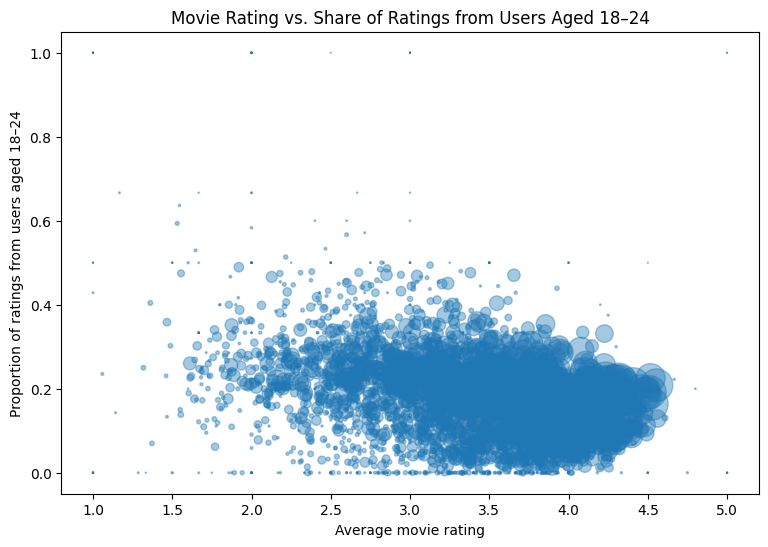

In [11]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

movie_age_ratings = ratings.merge(
    users[["user_id", "age"]],
    on="user_id"
)

movie_age_summary = (
    movie_age_ratings
    .assign(is_age_18_24=lambda x: x["age"] == 18)
    .groupby("movie_id")
    .agg(
        average_rating=("rating", "mean"),
        share_age_18_24=("is_age_18_24", "mean"),
        number_of_users=("user_id", "nunique")
    )
    .reset_index()
)

plt.figure(figsize=(9, 6))

plt.scatter(
    movie_age_summary["average_rating"],
    movie_age_summary["share_age_18_24"],
    s=movie_age_summary["number_of_users"] / 4,
    alpha=0.4
)

plt.xlabel("Average movie rating")
plt.ylabel("Proportion of ratings from users aged 18–24")
plt.title("Movie Rating vs. Share of Ratings from Users Aged 18–24")
plt.show()

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

In [12]:
# YOUR CODE HERE
# There are exactly 177 movies with zero ratings. An inner join would exclude movies that have no matching movie_id in ratings, so you would never be able to count—the zero-rating movies.
rating_counts = (
    ratings
    .groupby("movie_id")
    .size()
    .rename("number_of_ratings")
    .reset_index()
)

movies_with_rating_counts = (
    movies
    .merge(rating_counts, on="movie_id", how="left")
    .fillna({"number_of_ratings": 0})
)

movies_with_rating_counts["number_of_ratings"] = (
    movies_with_rating_counts["number_of_ratings"].astype(int)
)

zero_rating_movies = movies_with_rating_counts.query("number_of_ratings == 0")

len(zero_rating_movies)

177

6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

In [14]:
# YOUR CODE HERE
# 2986 movies received both a 1 and a 5 rating.
one_and_five = (
    ratings
    .query("rating in [1, 5]")
    .pivot_table(
        index="movie_id",
        columns="rating",
        values="user_id",
        aggfunc="size",
        fill_value=0
    )
    .rename(columns={1: "one_star_ratings", 5: "five_star_ratings"})
    .reset_index()
    .query("one_star_ratings > 0 and five_star_ratings > 0")
    .merge(movies[["movie_id", "title"]], on="movie_id")
    [["title", "one_star_ratings", "five_star_ratings"]]
    .sort_values("title")
)

one_and_five
len(one_and_five)

2986